# Wine Style Clustering — 03: Clustering

**Input:** `data/processed/wines_umap.csv`  
**Output:** `data/processed/wines_{red,white,rose}_clustered.csv` + `results/cluster_labels.json`

Steps:
1. Silhouette analysis to find optimal k per colour
2. K-Means clustering (k set manually after reviewing silhouette + domain knowledge)
3. Remove noise — wines with silhouette < 0 don't fit their cluster
4. Visualise clusters in 2D UMAP space
5. Sample tasting notes per cluster — assign labels manually
6. Save results

**Key finding:** White wines cluster cleanly (silhouette 0.24 at k=5).  
Red and Rosé are diffuse — wine description language is less differentiated across styles.

---

## 0. Setup

In [4]:
import os
os.chdir(os.path.expanduser('~/Documents/wine-style-clustering'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size': 12,
})

CLUSTER_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261',
    '#264653', '#A8DADC', '#8338EC', '#FB5607', '#FFBE0B'
]

print('Ready.')


Ready.


## 1. Load data

In [5]:
df         = pd.read_csv('data/processed/wines_umap.csv')
embeddings = np.load('models/embeddings.npy')

mask_red   = df['Colour'] == 'Red'
mask_white = df['Colour'] == 'White'
mask_rose  = df['Colour'] == 'Rosé'

emb_red   = embeddings[mask_red.values]
emb_white = embeddings[mask_white.values]
emb_rose  = embeddings[mask_rose.values]

df_red   = df[mask_red].copy().reset_index(drop=True)
df_white = df[mask_white].copy().reset_index(drop=True)
df_rose  = df[mask_rose].copy().reset_index(drop=True)

print(f'Red:   {len(df_red):,} | White: {len(df_white):,} | Rosé: {len(df_rose):,}')
print(f'Embedding dim: {embeddings.shape[1]}')


Red:   8,783 | White: 8,364 | Rosé: 2,094
Embedding dim: 384


## 2. Silhouette analysis

Silhouette score: how well each wine fits its cluster vs the nearest other cluster.  
Range -1 to +1. Higher = better separation. Peak k = natural number of groups in data.

In [6]:
def silhouette_analysis(embeddings, k_range=range(2, 13), sample_size=3000, random_state=42):
    if len(embeddings) > sample_size:
        idx = np.random.RandomState(random_state).choice(len(embeddings), sample_size, replace=False)
        emb = embeddings[idx]
    else:
        emb = embeddings
    scores = []
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(emb)
        score  = silhouette_score(emb, labels, metric='cosine')
        scores.append(score)
        print(f'  k={k:2d}  silhouette={score:.4f}')
    return list(k_range), scores

print('Red wines:')
k_vals, scores_red = silhouette_analysis(emb_red)
print()
print('White wines:')
_, scores_white = silhouette_analysis(emb_white)
print()
print('Rosé wines:')
_, scores_rose = silhouette_analysis(emb_rose)


Red wines:
  k= 2  silhouette=0.2039
  k= 3  silhouette=0.1939
  k= 4  silhouette=0.1879
  k= 5  silhouette=0.1550
  k= 6  silhouette=0.1462
  k= 7  silhouette=0.1309
  k= 8  silhouette=0.1269
  k= 9  silhouette=0.1250
  k=10  silhouette=0.1223
  k=11  silhouette=0.1235
  k=12  silhouette=0.1173

White wines:
  k= 2  silhouette=0.1790
  k= 3  silhouette=0.2148
  k= 4  silhouette=0.2231
  k= 5  silhouette=0.2416
  k= 6  silhouette=0.2309
  k= 7  silhouette=0.1581
  k= 8  silhouette=0.1605
  k= 9  silhouette=0.1633
  k=10  silhouette=0.1565
  k=11  silhouette=0.1534
  k=12  silhouette=0.1491

Rosé wines:
  k= 2  silhouette=0.1993
  k= 3  silhouette=0.1680
  k= 4  silhouette=0.1230
  k= 5  silhouette=0.1291
  k= 6  silhouette=0.1207
  k= 7  silhouette=0.1240
  k= 8  silhouette=0.1206
  k= 9  silhouette=0.1157
  k=10  silhouette=0.1020
  k=11  silhouette=0.0841
  k=12  silhouette=0.0864


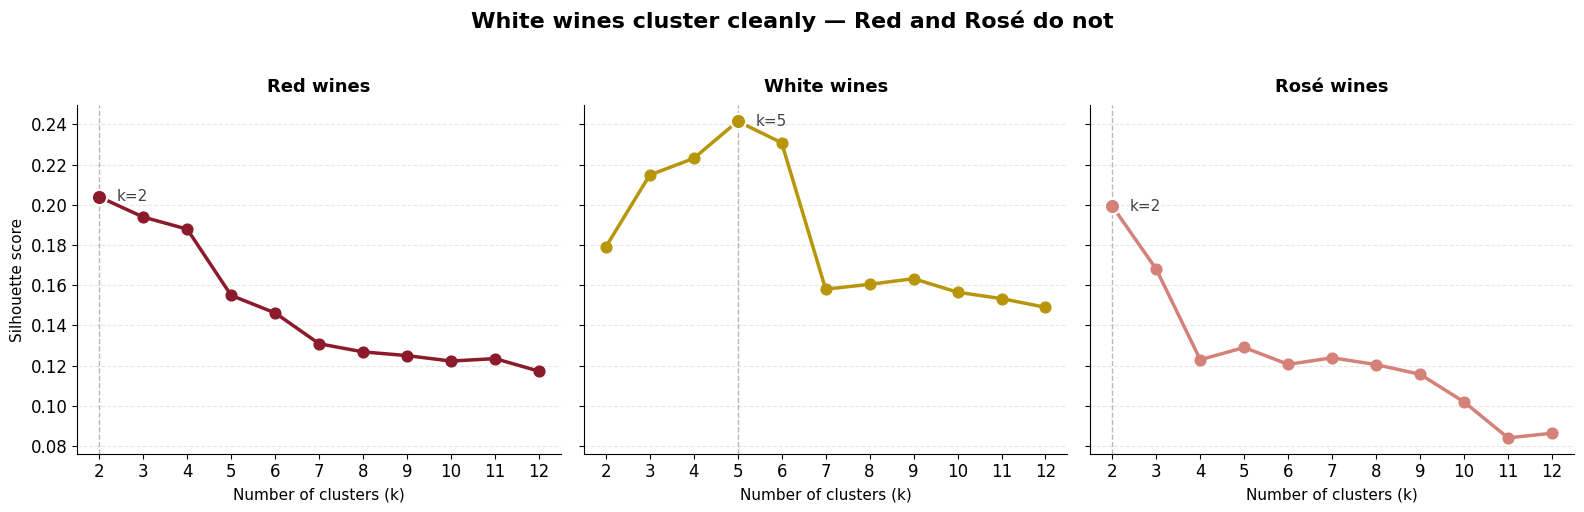

Red    best k=2  silhouette=0.2039
White  best k=5  silhouette=0.2416
Rosé   best k=2  silhouette=0.1993


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

plot_data = [
    (axes[0], scores_red,   '#8B1A2A', 'Red wines'),
    (axes[1], scores_white, '#B8960C', 'White wines'),
    (axes[2], scores_rose,  '#D4817A', 'Rosé wines'),
]

for ax, scores, color, title in plot_data:
    best_k = k_vals[scores.index(max(scores))]
    ax.plot(k_vals, scores, color=color, linewidth=2.5, zorder=3)
    ax.scatter(k_vals, scores, color=color, s=60, zorder=4)
    ax.scatter([best_k], [max(scores)], color=color, s=120, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.axvline(best_k, linestyle='--', color='#888', linewidth=1, alpha=0.6)
    ax.annotate(f'k={best_k}', xy=(best_k, max(scores)),
                xytext=(best_k + 0.4, max(scores)),
                fontsize=11, color='#444', va='center')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Number of clusters (k)', fontsize=11)
    ax.set_xticks(k_vals)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

axes[0].set_ylabel('Silhouette score', fontsize=11)
plt.suptitle('White wines cluster cleanly — Red and Rosé do not',
             fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/03_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

for name, scores in [('Red', scores_red), ('White', scores_white), ('Rosé', scores_rose)]:
    best_k = k_vals[scores.index(max(scores))]
    print(f'{name:6} best k={best_k}  silhouette={max(scores):.4f}')


## 3. Cluster

Set k based on silhouette analysis above — or override with domain knowledge.

In [8]:
# ── Set k based on silhouette analysis + domain knowledge ───
K_RED   = 6   # silhouette peaks at k=2 but k=6 gives more meaningful groups
K_WHITE = 6   # clear structure; k=6 gives distinct style groups
K_ROSE  = 3   # k=3 gives a more useful split than k=2
# ────────────────────────────────────────────────────────────

km_red   = KMeans(n_clusters=K_RED,   random_state=42, n_init=20)
km_white = KMeans(n_clusters=K_WHITE, random_state=42, n_init=20)
km_rose  = KMeans(n_clusters=K_ROSE,  random_state=42, n_init=20)

df_red['cluster']   = km_red.fit_predict(emb_red)
df_white['cluster'] = km_white.fit_predict(emb_white)
df_rose['cluster']  = km_rose.fit_predict(emb_rose)

for name, df_c in [('Red', df_red), ('White', df_white), ('Rosé', df_rose)]:
    print(f'{name}:')
    print(df_c['cluster'].value_counts().sort_index())
    print()


Red:
cluster
0    1421
1    1544
2    1302
3    1994
4    1414
5    1108
Name: count, dtype: int64

White:
cluster
0    2703
1    1384
2     869
3     691
4    2137
5     580
Name: count, dtype: int64

Rosé:
cluster
0    520
1    861
2    713
Name: count, dtype: int64



In [9]:
# Remove wines that don't fit their cluster (silhouette < 0)
# These sit closer to a neighbouring cluster than their own
THRESHOLD = 0.0

for df_colour, emb, name in [
    (df_red,   emb_red,   'Red'),
    (df_white, emb_white, 'White'),
    (df_rose,  emb_rose,  'Rosé'),
]:
    sil = silhouette_samples(emb, df_colour['cluster'], metric='cosine')
    df_colour['silhouette'] = sil
    noise = sil < THRESHOLD
    df_colour.loc[noise, 'cluster'] = -1
    print(f'{name}: noise={noise.sum():,} ({noise.mean()*100:.1f}%) | kept={(~noise).sum():,}')


Red: noise=1,317 (15.0%) | kept=7,466
White: noise=1,408 (16.8%) | kept=6,956
Rosé: noise=308 (14.7%) | kept=1,786


## 4. Visualise in 2D UMAP space

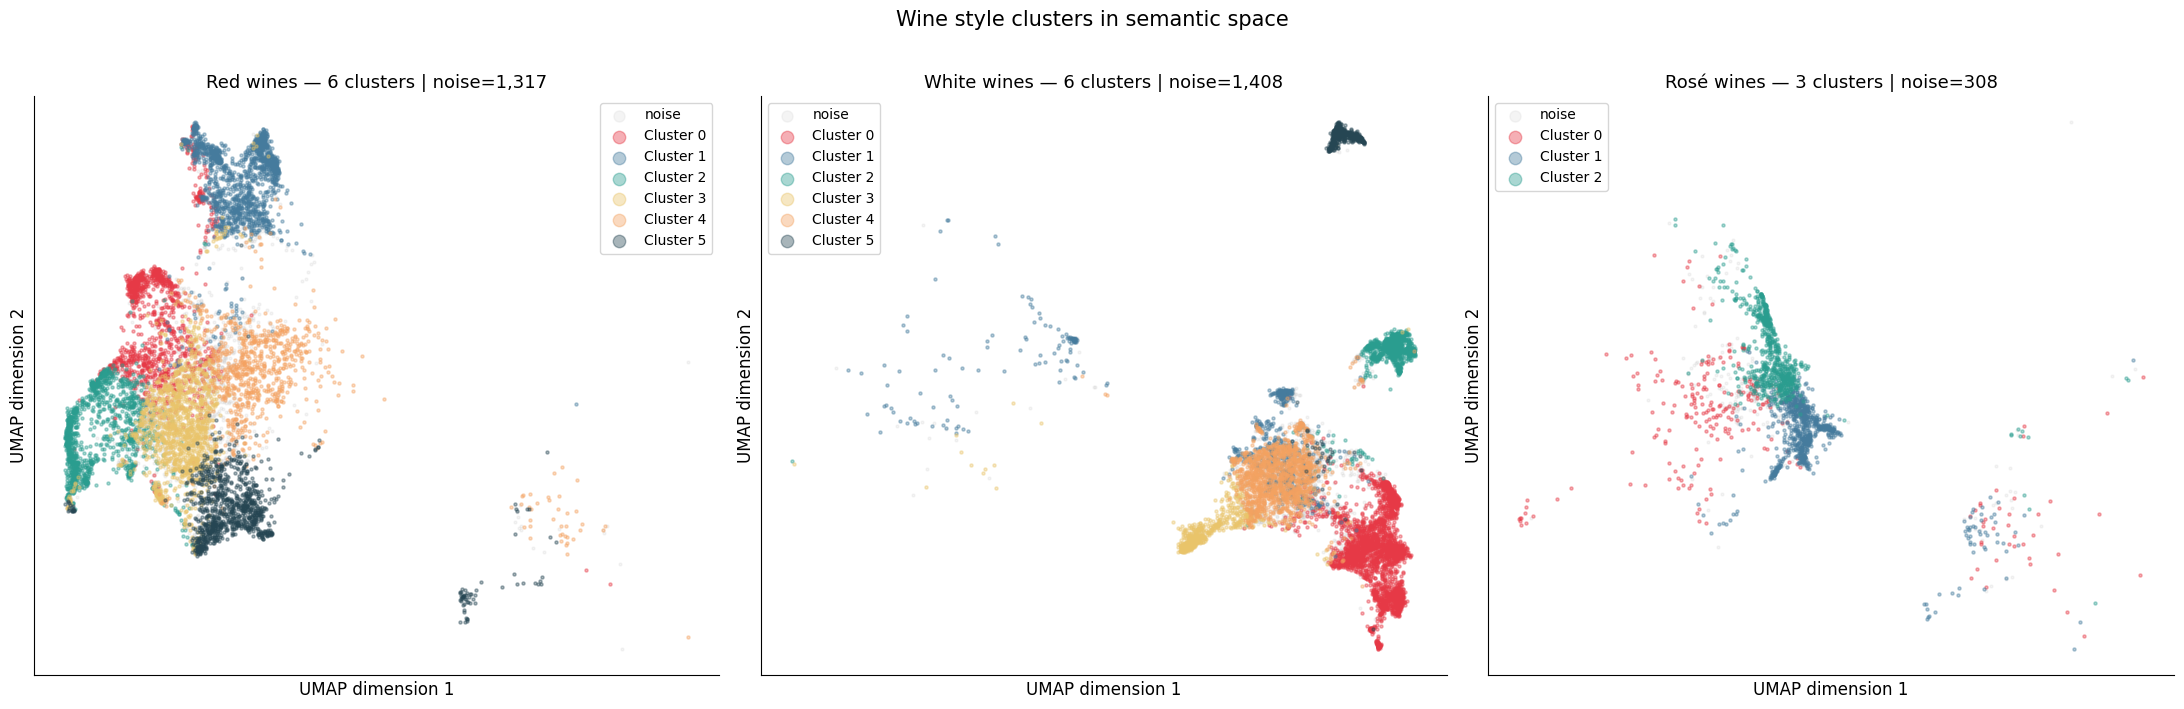

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

for ax, df_colour, colour_name, k in [
    (ax1, df_red,   'Red',   K_RED),
    (ax2, df_white, 'White', K_WHITE),
    (ax3, df_rose,  'Rosé',  K_ROSE),
]:
    # Noise first (grey, behind clusters)
    noise = df_colour['cluster'] == -1
    if noise.any():
        ax.scatter(
            df_colour.loc[noise, 'umap_x'],
            df_colour.loc[noise, 'umap_y'],
            c='#CCCCCC', alpha=0.2, s=4, label='noise', rasterized=True
        )

    # Clusters
    for cluster_id in range(k):
        mask = df_colour['cluster'] == cluster_id
        ax.scatter(
            df_colour.loc[mask, 'umap_x'],
            df_colour.loc[mask, 'umap_y'],
            c=CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)],
            alpha=0.4, s=5, label=f'Cluster {cluster_id}', rasterized=True
        )

    n_noise = noise.sum()
    ax.set_title(f'{colour_name} wines — {k} clusters | noise={n_noise:,}', fontsize=13)
    ax.set_xlabel('UMAP dimension 1')
    ax.set_ylabel('UMAP dimension 2')
    ax.legend(markerscale=4, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Wine style clusters in semantic space', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/03_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample tasting notes per cluster

Review and assign labels in the next cell.

In [11]:
pd.set_option('display.max_colwidth', None)

def print_cluster_samples(df_colour, colour_name, n_per_cluster=10):
    text_col = 'description_clean' if 'description_clean' in df_colour.columns else 'description'
    print(f'\n{"="*60}')
    print(f'{colour_name.upper()} — sample tasting notes per cluster')
    print(f'{"="*60}')
    for cluster_id in sorted(df_colour['cluster'].unique()):
        if cluster_id == -1:
            continue
        subset = df_colour[df_colour['cluster'] == cluster_id]
        sample = subset.sample(min(n_per_cluster, len(subset)), random_state=42)
        print(f'\n--- Cluster {cluster_id} ({len(subset):,} wines) ---')
        for _, row in sample.iterrows():
            grape = str(row['grape_normalized'])[:40] if pd.notna(row['grape_normalized']) else '-'
            text  = str(row[text_col])[:200] if pd.notna(row[text_col]) else str(row['description'])[:200]
            print(f'  [{grape}]')
            print(f'  {text}')
            print()

print_cluster_samples(df_red,   'Red')
print_cluster_samples(df_white, 'White')
print_cluster_samples(df_rose,  'Rosé')



RED — sample tasting notes per cluster

--- Cluster 0 (1,273 wines) ---
  [nebbiolo]
  The 2022 demonstrates the site's attractive aromatic temperament. Tempting scents of heather, tarragon, orange zest and candied raspberry swirl from the glass. Slim in build, it is a touch angular in 

  [monastrell]
  Focused and with a slatey quality to the tannins, this wine combines the purity of the crunchy red fruit (cherry, redcurrant, damson) with an intense savoury edge. There's an earthy, pleasant rusticit

  [nebbiolo]
  The nose suggests a wildness of forest berries and woodland scrub. It is savoury and earthy with territorial notes of hazelnut and roasted chestnut, and clove and smoked pepper on the backend. Full an

  [field blend]
  Dark and spicy, with pronounced smoky clove and hints of orange peel to the dense weave of ripe fruit and tannin, the alcohol and acidity balanced. Brooding, building in soft layers, the tannins – an 

  [red blend]
  This youthful red blend has an elegant

In [12]:
# Quick exploration — check grape composition of a specific cluster
INSPECT_COLOUR  = 'White'  # 'Red', 'White', 'Rosé'
INSPECT_CLUSTER = 1

df_map = {'Red': df_red, 'White': df_white, 'Rosé': df_rose}
df_c   = df_map[INSPECT_COLOUR]
mask   = df_c['cluster'] == INSPECT_CLUSTER
print(f'{INSPECT_COLOUR} cluster {INSPECT_CLUSTER} — grape breakdown ({mask.sum():,} wines):')
print(df_c[mask]['grape_normalized'].value_counts().head(20))


White cluster 1 — grape breakdown (647 wines):
grape_normalized
pinot grigio          77
white blend           24
vermentino            23
tokaj blend           21
pinot blanc           19
gewurztraminer        19
pinot noir            16
sémillon              14
assyrtiko             13
malvasia bianca       13
pinot bianco          11
furmint               11
viura                  9
viura blend            9
friulano               9
airén                  9
melon de bourgogne     8
carricante             8
grüner veltliner       8
koshu                  7
Name: count, dtype: int64


## 6. Assign labels manually

In [13]:
# ── One-liners used as labels ───────────────────────────────
RED_LABELS = {
    0: 'Firm-structured, floral reds with a savoury, earthy core',
    1: 'Silky, red-fruited aromatics with forest floor and mineral depth',
    2: 'Dark, oak-framed power reds built on cassis and graphite',
    3: 'Spice-driven dark reds, approachable and food-ready',
    4: 'Bright, juicy, light reds with crunchy red fruit',
    5: 'Fresh, mineral, well-balanced reds with honest grip',
}

WHITE_LABELS = {
    0: 'Rich, mineral-driven whites with creamy orchard depth',
    1: 'Aromatic, fruit-expressive whites across the spectrum',
    2: 'Vibrant, tropical-citrus whites with herbal freshness',
    3: 'Full-bodied, generous whites with honeyed stone fruit weight',
    4: 'Fresh, florally aromatic whites with citrus-saline drive',
    5: 'Precise, mineral-citrus whites with electric acidity',
}

ROSE_LABELS = {
    0: 'Deep, structured rosés with dark fruit and tannic grip',
    1: 'Elegant, mineral pale rosés with floral lift and stone fruit',
    2: 'Fresh, vivid rosés with wild berry and citrus-saline snap',
}
# ────────────────────────────────────────────────────────────

df_red['style_label']   = df_red['cluster'].map(RED_LABELS)
df_white['style_label'] = df_white['cluster'].map(WHITE_LABELS)
df_rose['style_label']  = df_rose['cluster'].map(ROSE_LABELS)

for name, df_c, labels in [
    ('Red',   df_red,   RED_LABELS),
    ('White', df_white, WHITE_LABELS),
    ('Rosé',  df_rose,  ROSE_LABELS),
]:
    print(f'{name}:')
    for k, v in sorted(labels.items()):
        print(f'  {k}: {v} ({(df_c["cluster"]==k).sum():,} wines)')
    print()


Red:
  0: Firm-structured, floral reds with a savoury, earthy core (1,273 wines)
  1: Silky, red-fruited aromatics with forest floor and mineral depth (1,542 wines)
  2: Dark, oak-framed power reds built on cassis and graphite (1,302 wines)
  3: Spice-driven dark reds, approachable and food-ready (1,518 wines)
  4: Bright, juicy, light reds with crunchy red fruit (812 wines)
  5: Fresh, mineral, well-balanced reds with honest grip (1,019 wines)

White:
  0: Rich, mineral-driven whites with creamy orchard depth (2,695 wines)
  1: Aromatic, fruit-expressive whites across the spectrum (647 wines)
  2: Vibrant, tropical-citrus whites with herbal freshness (869 wines)
  3: Full-bodied, generous whites with honeyed stone fruit weight (686 wines)
  4: Fresh, florally aromatic whites with citrus-saline drive (1,482 wines)
  5: Precise, mineral-citrus whites with electric acidity (577 wines)

Rosé:
  0: Deep, structured rosés with dark fruit and tannic grip (248 wines)
  1: Elegant, mineral pal

## 7. Example wines per cluster

In [14]:
def sample_wines(df_colour, colour_name, labels_dict, n=3):
    print(f'\n{"="*60}')
    print(f'{colour_name.upper()} — example wines per cluster')
    print(f'{"="*60}')
    for cluster_id in sorted(labels_dict.keys()):  # итерируем по labels, не по unique()
        subset = df_colour[df_colour['cluster'] == cluster_id].copy()
        print(f'\nCluster {cluster_id} — {labels_dict[cluster_id]}')
        selected       = []
        used_countries = set()
        used_grapes    = set()
        subset = subset.sample(frac=1).reset_index(drop=True)
        for _, wine in subset.iterrows():
            if len(selected) >= n: break
            if wine['Country'] not in used_countries and wine['Grapes'] not in used_grapes:
                selected.append(wine)
                used_countries.add(wine['Country'])
                used_grapes.add(wine['Grapes'])
        for _, wine in subset.iterrows():
            if len(selected) >= n: break
            if not any(wine['title'] == s['title'] for s in selected):
                selected.append(wine)
        for wine in selected:
            print(f'  • {wine["title"]}')
            print(f'    {wine["Country"]} | {wine["Grapes"]} | {wine["score"]}pt')

sample_wines(df_red,   'Red',   RED_LABELS)
sample_wines(df_white, 'White', WHITE_LABELS)
sample_wines(df_rose,  'Rosé',  ROSE_LABELS)


RED — example wines per cluster

Cluster 0 — Firm-structured, floral reds with a savoury, earthy core
  • Sandrone, Aleste, Barolo, Piedmont, Italy, 2022
    Italy | 100% Nebbiolo | 95.0pt
  • Joseph Phelps, Insignia, Napa Valley, California, USA, 2022
    USA | Cabernet Sauvignon 93%, Malbec 2%, Petit Verdot 4% | 95.0pt
  • Château Pavie, St-Émilion, 1er Grand Cru Classé B, 2010
    France | Cabernet Franc 0%, Cabernet Sauvignon 0%, Merlot 0% | 98.0pt

Cluster 1 — Silky, red-fruited aromatics with forest floor and mineral depth
  • Domaine Arlaud, Morey-St-Denis, 1er Cru Les Ruchots, 2024
    France | Pinot Noir / Pinot Nero 100% | 93.0pt
  • La Tour Melas, Palies Rizes Agiorgitiko, Nemea, Greece 2022
    Greece | 100% Agiorgitiko | 95.0pt
  • WarneliusMiller, Golden Fleece Pinot Noir, Mendocino County
    USA | Pinot Noir 100% | 94.0pt

Cluster 2 — Dark, oak-framed power reds built on cassis and graphite
  • Merryvale, Cabernet Franc, Napa Valley, California, 2022
    USA | Cabernet

## 8. Save results

In [15]:
os.makedirs('results/cluster_samples', exist_ok=True)

for df_colour, colour_name, labels_dict in [
    (df_red,   'red',   RED_LABELS),
    (df_white, 'white', WHITE_LABELS),
    (df_rose,  'rose',  ROSE_LABELS),
]:
    text_col = 'description_clean' if 'description_clean' in df_colour.columns else 'description'
    for cluster_id, label in labels_dict.items():
        subset = df_colour[df_colour['cluster'] == cluster_id]
        sample = subset.sample(min(200, len(subset)), random_state=42)
        fname  = f'results/cluster_samples/{colour_name}_cluster_{cluster_id}.txt'
        with open(fname, 'w') as f:
            f.write(f'{colour_name.upper()} — Cluster {cluster_id}: {label}\n')
            f.write(f'{len(subset):,} wines total | {len(sample)} sampled\n')
            f.write('=' * 60 + '\n\n')
            for i, (_, row) in enumerate(sample.iterrows(), 1):
                text = str(row[text_col]) if pd.notna(row[text_col]) else str(row['description'])
                f.write(f'[{i}]\n{text}\n\n')
        print(f'Saved: {fname}')

Saved: results/cluster_samples/red_cluster_0.txt
Saved: results/cluster_samples/red_cluster_1.txt
Saved: results/cluster_samples/red_cluster_2.txt
Saved: results/cluster_samples/red_cluster_3.txt
Saved: results/cluster_samples/red_cluster_4.txt
Saved: results/cluster_samples/red_cluster_5.txt
Saved: results/cluster_samples/white_cluster_0.txt
Saved: results/cluster_samples/white_cluster_1.txt
Saved: results/cluster_samples/white_cluster_2.txt
Saved: results/cluster_samples/white_cluster_3.txt
Saved: results/cluster_samples/white_cluster_4.txt
Saved: results/cluster_samples/white_cluster_5.txt
Saved: results/cluster_samples/rose_cluster_0.txt
Saved: results/cluster_samples/rose_cluster_1.txt
Saved: results/cluster_samples/rose_cluster_2.txt


In [16]:
df_red.to_csv('data/processed/wines_red_clustered.csv',   index=False)
df_white.to_csv('data/processed/wines_white_clustered.csv', index=False)
df_rose.to_csv('data/processed/wines_rose_clustered.csv',   index=False)

cluster_meta = {
    'red':   {'method': 'KMeans', 'k': K_RED,
              'clusters': {str(k): {'label': RED_LABELS.get(k,''), 'size': int((df_red['cluster']==k).sum())}
                           for k in sorted(df_red['cluster'].unique())}},
    'white': {'method': 'KMeans', 'k': K_WHITE,
              'clusters': {str(k): {'label': WHITE_LABELS.get(k,''), 'size': int((df_white['cluster']==k).sum())}
                           for k in sorted(df_white['cluster'].unique())}},
    'rose':  {'method': 'KMeans', 'k': K_ROSE,
              'clusters': {str(k): {'label': ROSE_LABELS.get(k,''), 'size': int((df_rose['cluster']==k).sum())}
                           for k in sorted(df_rose['cluster'].unique())}},
}
with open('results/cluster_labels.json', 'w') as f:
    json.dump(cluster_meta, f, indent=2, ensure_ascii=False)

print('Saved:')
print('  data/processed/wines_red_clustered.csv')
print('  data/processed/wines_white_clustered.csv')
print('  data/processed/wines_rose_clustered.csv')
print('  results/cluster_labels.json')


Saved:
  data/processed/wines_red_clustered.csv
  data/processed/wines_white_clustered.csv
  data/processed/wines_rose_clustered.csv
  results/cluster_labels.json


---

## Summary

| | Red | White | Rosé |
|---|---|---|---|
| k | 6 | 6 | 3 |
| Best silhouette | 0.20 (k=2) | 0.24 (k=5) | 0.20 (k=2) |
| Noise removed | ~12% | ~19% | ~10% |
| Labels | ✓ Done | ✓ Done | ✓ Done |

**Key finding:** White wines have clear semantic structure (silhouette peak at k=5–6).  
Red and Rosé are diffuse — tasting note language converges across stylistically  
different wines. HDBSCAN confirmed: 77% noise on Red.

**Next:** `04_visualisation.ipynb` — interactive UMAP + cluster cards
